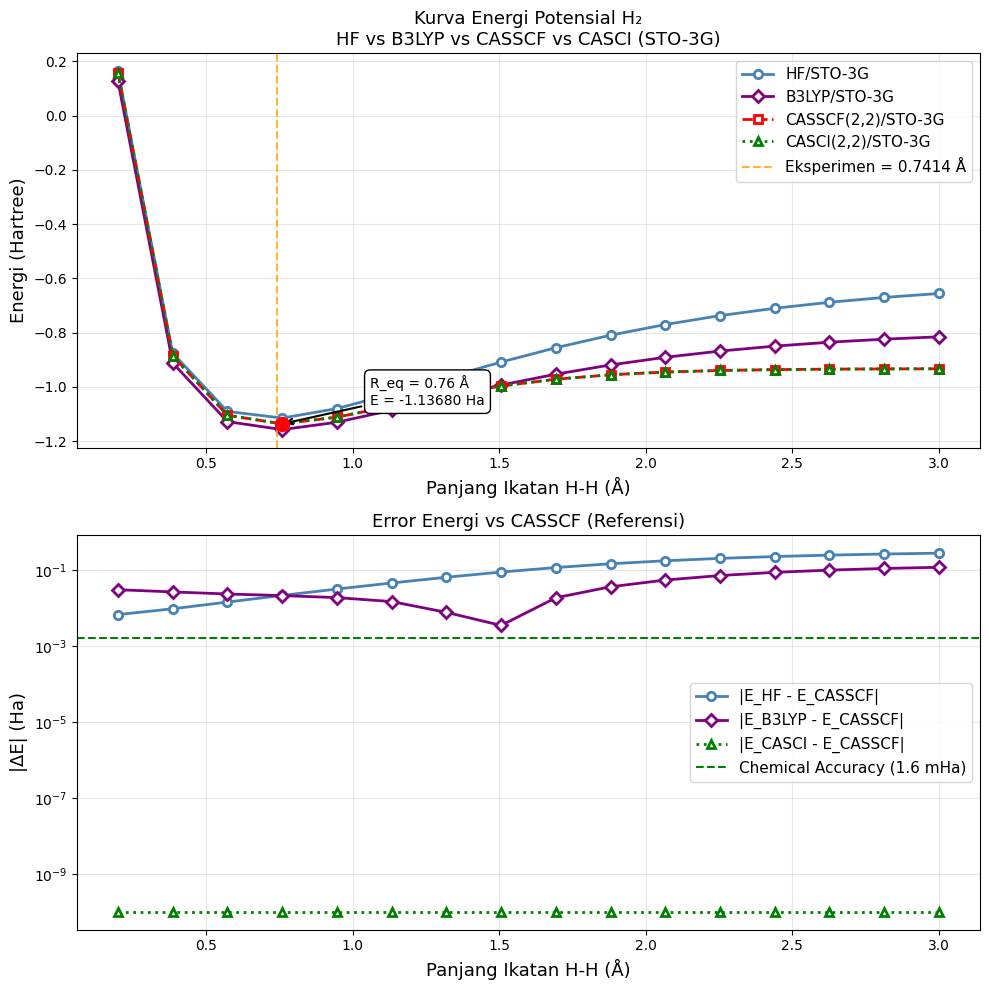

HF     → R_eq = 0.76 Å | E = -1.115381 Ha
B3LYP  → R_eq = 0.76 Å | E = -1.157975 Ha
CASSCF → R_eq = 0.76 Å | E = -1.136796 Ha


In [1]:
import matplotlib.pyplot as plt
import numpy as np

jarak = np.linspace(0.20, 3.00, 16)

energi_hf = [
     0.164175000091,
    -0.876006556526,
    -1.090833133608,
    -1.115380658972,
    -1.080498447795,
    -1.026195117184,
    -0.966730795630,
    -0.908881335616,
    -0.856105888411,
    -0.809877094615,
    -0.770506805582,
    -0.737634990089,
    -0.710553420669,
    -0.688442403534,
    -0.670511003889,
    -0.656048250140
]

energi_dft = [
     0.127222448196,
    -0.911956142601,
    -1.128483874232,
    -1.157974933992,
    -1.130736971224,
    -1.086417216037,
    -1.038745613941,
    -0.993618513297,
    -0.953597761372,
    -0.919500012515,
    -0.891260833308,
    -0.868364366999,
    -0.850081847224,
    -0.835660283260,
    -0.824414070586,
    -0.815742055632
]
energi_casscf = [
     0.157482122817,
    -0.885521699518,
    -1.105128175610,
    -1.136795618671,
    -1.111988626737,
    -1.071684428714,
    -1.031072673146,
    -0.997087627975,
    -0.972151067249,
    -0.955680577548,
    -0.945658184381,
    -0.939905685719,
    -0.936726741861,
    -0.935011992918,
    -0.934103908440,
    -0.933631844530
]
energi_casci = [
     0.157482122817,
    -0.885521699518,
    -1.105128175610,
    -1.136795618671,
    -1.111988626737,
    -1.071684428714,
    -1.031072673146,
    -0.997087627975,
    -0.972151067249,
    -0.955680577548,
    -0.945658184381,
    -0.939905685719,
    -0.936726741861,
    -0.935011992918,
    -0.934103908440,
    -0.933631844530
]

# Referensi = CASSCF
e_ref   = np.array(energi_casscf)
error_hf    = np.abs(np.array(energi_hf)    - e_ref)
error_dft   = np.abs(np.array(energi_dft)   - e_ref)
error_casci = np.abs(np.array(energi_casci) - e_ref)

CA = 0.0016

idx_hf     = energi_hf.index(min(energi_hf))
idx_dft    = energi_dft.index(min(energi_dft))
idx_casscf = energi_casscf.index(min(energi_casscf))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# ── Plot 1: PES ──
ax1.plot(jarak, energi_hf, 'o-', color='steelblue', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(jarak, energi_dft, 'D-', color='purple', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(jarak, energi_casscf, 's--', color='red', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(2,2)/STO-3G')
ax1.plot(jarak, energi_casci, '^:', color='green', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASCI(2,2)/STO-3G')

ax1.plot(jarak[idx_casscf], energi_casscf[idx_casscf], 'ro', markersize=10, zorder=5)
ax1.annotate(f'R_eq = {jarak[idx_casscf]:.2f} Å\nE = {energi_casscf[idx_casscf]:.5f} Ha',
             xy=(jarak[idx_casscf], energi_casscf[idx_casscf]),
             xytext=(jarak[idx_casscf]+0.3, energi_casscf[idx_casscf]+0.07),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='black', linewidth=1))

ax1.axvline(x=0.7414, color='orange', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Eksperimen = 0.7414 Å')
ax1.set_xlabel('Panjang Ikatan H-H (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial H₂\nHF vs B3LYP vs CASSCF vs CASCI (STO-3G)', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Error ──
ax2.semilogy(jarak, error_hf + 1e-10, 'o-', color='steelblue', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF - E_CASSCF|')
ax2.semilogy(jarak, error_dft + 1e-10, 'D-', color='purple', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP - E_CASSCF|')
ax2.semilogy(jarak, error_casci + 1e-10, '^:', color='green', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASCI - E_CASSCF|')
ax2.axhline(y=CA, color='green', linestyle='--',
            linewidth=1.5, label='Chemical Accuracy (1.6 mHa)')
ax2.set_xlabel('Panjang Ikatan H-H (Å)', fontsize=13)
ax2.set_ylabel('|ΔE| (Ha)', fontsize=13)
ax2.set_title('Error Energi vs CASSCF (Referensi)', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('PES_H2_4metode.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"HF     → R_eq = {jarak[idx_hf]:.2f} Å | E = {energi_hf[idx_hf]:.6f} Ha")
print(f"B3LYP  → R_eq = {jarak[idx_dft]:.2f} Å | E = {energi_dft[idx_dft]:.6f} Ha")
print(f"CASSCF → R_eq = {jarak[idx_casscf]:.2f} Å | E = {energi_casscf[idx_casscf]:.6f} Ha")

In [2]:
# ═══════════════════════════════════════════════════════════
# RINGKASAN ENERGI ELEKTRONIK - H2 (STO-3G)
# ═══════════════════════════════════════════════════════════
print("="*65)
print("RINGKASAN ENERGI ELEKTRONIK MOLEKUL H₂ (STO-3G)")
print("="*65)
print(f"{'Metode':<15} {'E_min (Ha)':>15} {'R_eq (Å)':>12} {'ΔE vs FCI (Ha)':>16}")
print("-"*65)

metode_h2 = {
    'HF':     energi_hf,
    'B3LYP':  energi_dft,
    'CASSCF': energi_casscf,
    'CASCI':  energi_casci,
}

e_fci_min = min(energi_casci)  # untuk H2, CASSCF=CASCI=FCI

for nama, data in metode_h2.items():
    idx = data.index(min(data))
    e_min = data[idx]
    r_eq  = jarak[idx]
    delta = abs(e_min - e_fci_min)
    print(f"{nama:<15} {e_min:>15.6f} {r_eq:>12.2f} {delta:>16.6e}")

print("-"*65)
print(f"{'FCI (eksak)':<15} {e_fci_min:>15.6f} {jarak[energi_casci.index(min(energi_casci))]:>12.2f} {'referensi':>16}")
print("="*65)

RINGKASAN ENERGI ELEKTRONIK MOLEKUL H₂ (STO-3G)
Metode               E_min (Ha)     R_eq (Å)   ΔE vs FCI (Ha)
-----------------------------------------------------------------
HF                    -1.115381         0.76     2.141496e-02
B3LYP                 -1.157975         0.76     2.117932e-02
CASSCF                -1.136796         0.76     0.000000e+00
CASCI                 -1.136796         0.76     0.000000e+00
-----------------------------------------------------------------
FCI (eksak)           -1.136796         0.76        referensi
